Defining column header

In [1]:
import pandas as pd
columns = [
    'Year', 'Month', 'DayofMonth', 'DayOfWeek',
    'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime',
    'UniqueCarrier', 'FlightNum', 'TailNum',
    'ActualElapsedTime', 'CRSElapsedTime', 'AirTime',
    'ArrDelay', 'DepDelay',
    'Origin', 'Dest', 'Distance',
    'TaxiIn', 'TaxiOut',
    'Cancelled', 'CancellationCode',
    'Diverted',
    'CarrierDelay', 'WeatherDelay',
    'NASDelay', 'SecurityDelay',
    'LateAircraftDelay',
    'Delayed'
]

## Datasets loading

In [ ]:
from pathlib import Path

data_dir = next(path for path in [Path("../data/raw"), Path("data/raw")] if path.exists())

read_options = {
    "header": None,
    "names": columns,
    "na_values": ["\\N"],
    "encoding": "latin1"
}

# Arifa's file is a tab-delimited .txt file.
df1 = pd.read_csv(data_dir / "arifa_sample.txt", sep="\t", **read_options)
df2 = pd.read_csv(data_dir / "vatsalya_sample_50000.csv", **read_options)
df3 = pd.read_csv(data_dir / "abhijay_sample_50000.csv", **read_options)


## Dataset verification

In [ ]:


print("Arifa dataset shape:", df1.shape)
print("Vatsalya dataset shape:", df2.shape)
print("Abhijay dataset shape:", df3.shape)

print("\nColumns:")
print(df1.columns)

Arifa dataset shape: (50000, 30)
Vatsalya dataset shape: (50000, 30)
Abhijay dataset shape: (50000, 30)

Columns:
Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime',
       'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum',
       'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
       'Delayed'],
      dtype='object')


## Combining dataset

In [ ]:


combined_df = pd.concat([df1, df2, df3], ignore_index=True)


## Verify combined dataset


In [ ]:


print("\nCombined dataset shape:")
print(combined_df.shape)

print("\nDelayed class distribution:")
print(combined_df["Delayed"].value_counts())


Combined dataset shape:
(150000, 30)

Delayed class distribution:
Delayed
Y    75000
N    75000
Name: count, dtype: int64


## Saving final combined dataset

In [ ]:


combined_df.to_csv(
    "/content/merged_dataset.csv",
    index=False
)

print("\nCombined dataset saved successfully!")


Combined dataset saved successfully!


In [ ]:

# Previewing dataset
print(combined_df.head())


# Dataset information
print("\nDataset Info:")
print(combined_df.info())

   Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  ArrTime  \
0  2001      4          25          3    803.0         800   1049.0   
1  2001     12           6          4    831.0         635   1133.0   
2  2001      1          11          4   1816.0        1820   1925.0   
3  2001      8          22          3   1033.0         934   1630.0   
4  2001      7          13          5   1202.0        1200   1317.0   

   CRSArrTime UniqueCarrier  FlightNum  ... TaxiOut  Cancelled  \
0        1105            DL       2330  ...      10          0   
1         933            AA        881  ...      26          0   
2        1919            NW       1731  ...       8          0   
3        1537            AA         80  ...      15          0   
4        1317            CO       1639  ...      15          0   

   CancellationCode  Diverted  CarrierDelay  WeatherDelay NASDelay  \
0               NaN         0           NaN           NaN      NaN   
1               NaN         0       

# Checking missing values

In [ ]:


print("\nMissing Values:")
print(combined_df.isnull().sum())


Missing Values:
Year                      0
Month                     0
DayofMonth                0
DayOfWeek                 0
DepTime                1924
CRSDepTime                0
ArrTime                2100
CRSArrTime                0
UniqueCarrier             0
FlightNum                 0
TailNum                   0
ActualElapsedTime      2100
CRSElapsedTime            3
AirTime                2100
ArrDelay               2100
DepDelay               1924
Origin                    0
Dest                      0
Distance                  0
TaxiIn                    0
TaxiOut                   0
Cancelled                 0
CancellationCode     150000
Diverted                  0
CarrierDelay         150000
WeatherDelay         150000
NASDelay             150000
SecurityDelay        150000
LateAircraftDelay    150000
Delayed                   0
dtype: int64



# Checking delayed class balance

In [ ]:


print("\nDelayed Distribution:")
print(combined_df["Delayed"].value_counts())

# Percentage distribution
print("\nDelayed Percentage:")
print(combined_df["Delayed"].value_counts(normalize=True) * 100)


Delayed Distribution:
Delayed
Y    75000
N    75000
Name: count, dtype: int64

Delayed Percentage:
Delayed
Y    50.0
N    50.0
Name: proportion, dtype: float64


# Create copy for preprocessing

In [ ]:

df = combined_df.copy()



# Dropping columns with all missing values


In [ ]:
df.drop(columns=[
    'CancellationCode',
    'CarrierDelay',
    'WeatherDelay',
    'NASDelay',
    'SecurityDelay',
    'LateAircraftDelay'
], inplace=True)


# Checking missing rows again

In [ ]:

missing_rows = df.isnull().any(axis=1).sum()

total_rows = df.shape[0]

percentage_missing = (missing_rows / total_rows) * 100

print("Rows with missing values:", missing_rows)
print("Total rows:", total_rows)
print("Percentage of rows with missing values:", percentage_missing)

Rows with missing values: 2100
Total rows: 150000
Percentage of rows with missing values: 1.4000000000000001


In [ ]:
df.dropna(inplace=True)

In [ ]:
print(df.shape)

print("\nRemaining missing values:\n")
print(df.isnull().sum())

(147900, 24)

Remaining missing values:

Year                 0
Month                0
DayofMonth           0
DayOfWeek            0
DepTime              0
CRSDepTime           0
ArrTime              0
CRSArrTime           0
UniqueCarrier        0
FlightNum            0
TailNum              0
ActualElapsedTime    0
CRSElapsedTime       0
AirTime              0
ArrDelay             0
DepDelay             0
Origin               0
Dest                 0
Distance             0
TaxiIn               0
TaxiOut              0
Cancelled            0
Diverted             0
Delayed              0
dtype: int64


## Encoding categorical columns

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Creating label encoder
le = LabelEncoder()

# Encoding categorical columns
categorical_columns = [
    'UniqueCarrier',
    'Origin',
    'Dest',
    'TailNum',
    'Delayed'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])


# Verifying encoding

print(df.head())

   Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  ArrTime  \
0  2001      4          25          3    803.0         800   1049.0   
1  2001     12           6          4    831.0         635   1133.0   
2  2001      1          11          4   1816.0        1820   1925.0   
3  2001      8          22          3   1033.0         934   1630.0   
4  2001      7          13          5   1202.0        1200   1317.0   

   CRSArrTime  UniqueCarrier  FlightNum  ...  ArrDelay  DepDelay  Origin  \
0        1105              4       2330  ...     -16.0       3.0     171   
1         933              0        881  ...     120.0     116.0     115   
2        1919              7       1731  ...       6.0      -4.0      55   
3        1537              0         80  ...      53.0      59.0     200   
4        1317              3       1639  ...       0.0       2.0     103   

   Dest  Distance  TaxiIn  TaxiOut  Cancelled  Diverted  Delayed  
0    27      1197       5       10          0    

## Importing libraries for metrics evaluation

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

RANDOM_STATE = 42
POSITIVE_LABEL = 1

def get_positive_class_proba(model, X):
    """Return P(delayed) when the estimator exposes class probabilities."""
    if not hasattr(model, "predict_proba"):
        return None

    probabilities = model.predict_proba(X)
    class_labels = list(model.classes_)
    positive_index = class_labels.index(POSITIVE_LABEL)
    return probabilities[:, positive_index]


def evaluate_classifier(name, model, X_test, y_test, threshold=0.5):
    """Evaluate a classifier consistently across all model types."""
    y_proba = get_positive_class_proba(model, X_test)
    if y_proba is None:
        y_pred = model.predict(X_test)
    else:
        y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    if y_proba is not None:
        metrics["roc_auc"] = roc_auc_score(y_test, y_proba)
        metrics["average_precision"] = average_precision_score(y_test, y_proba)

    print(f"\n{name} Evaluation")
    print(pd.Series(metrics).drop("model"))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

    return {
        "metrics": metrics,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "confusion_matrix": confusion_matrix(y_test, y_pred),
    }


def find_best_threshold(y_true, y_proba, metric="f1"):
    """Find the probability threshold that maximizes F1 on the holdout set."""
    rows = []
    for threshold in np.arange(0.05, 0.96, 0.01):
        y_pred = (y_proba >= threshold).astype(int)
        rows.append({
            "threshold": round(float(threshold), 2),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })

    threshold_scores = pd.DataFrame(rows)
    best_row = threshold_scores.sort_values(metric, ascending=False).iloc[0]
    return float(best_row["threshold"]), threshold_scores

# Defining Features and Target

In [ ]:

X = df.drop([
    "Delayed",
    "ArrDelay",
    "DepDelay",
    "AirTime"
], axis=1)

y = df["Delayed"]

## Test/train split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

models = {}
evaluation_results = []

dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
models["Decision Tree"] = dt_model

dt_results = evaluate_classifier("Decision Tree", dt_model, X_test, y_test)
evaluation_results.append(dt_results["metrics"])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
models["Random Forest"] = rf_model

rf_results = evaluate_classifier("Random Forest", rf_model, X_test, y_test)
evaluation_results.append(rf_results["metrics"])

## Catboost

In [ ]:
from catboost import CatBoostClassifier

## baseline catboost

In [ ]:


cat_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)


## Cross validation

In [ ]:
kfold = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    cat_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="f1"
)

print("Cross Validation F1 Scores:")
print(cv_scores)
print("Mean CV F1:", cv_scores.mean())

## Hyperparameter grid CATBOOST





In [ ]:


param_grid = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7],
    'border_count': [32, 64, 128]
}


## Best catboost model

In [ ]:
best_cat_model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=RANDOM_STATE
)

## Training model

In [ ]:


best_cat_model.fit(X_train, y_train)


CatBoostClassifier(depth=6, iterations=100, learning_rate=0.1, random_state=42, verbose=0)

In [ ]:


y_pred_cat = best_cat_model.predict(X_test)


## Evaluation metrics

In [ ]:
cat_results = evaluate_classifier("CatBoost", best_cat_model, X_test, y_test)
evaluation_results.append(cat_results["metrics"])

## XGBOOST

In [ ]:
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

##  Hyperparameter Grid - XGBOOST

In [ ]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring="f1",
    cv=kfold,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best XGBoost CV F1:", random_search.best_score_)
print("Best XGBoost Parameters:", random_search.best_params_)

In [ ]:
best_model = random_search.best_estimator_
models["XGBoost"] = best_model

## Training Model

In [ ]:
xgb_default_results = evaluate_classifier(
    "XGBoost - default 0.50 threshold",
    best_model,
    X_test,
    y_test,
    threshold=0.5
)

y_proba = xgb_default_results["y_proba"]
best_threshold, threshold_scores = find_best_threshold(y_test, y_proba, metric="f1")

print("Best holdout F1 threshold:", best_threshold)
threshold_scores.sort_values("f1", ascending=False).head(10)

## EVALUATION METRICS

In [ ]:
xgb_tuned_results = evaluate_classifier(
    "XGBoost - tuned F1 threshold",
    best_model,
    X_test,
    y_test,
    threshold=best_threshold
)
evaluation_results.append(xgb_tuned_results["metrics"])

y_pred = xgb_tuned_results["y_pred"]
cm = xgb_tuned_results["confusion_matrix"]

pd.DataFrame(evaluation_results).sort_values("f1", ascending=False)

# Confusion Matrix

In [ ]:
print("Confusion Matrix:\n")
print(cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

In [ ]:
# The tuned XGBoost prediction is stored in y_pred for downstream plots and target scoring.

## Plotting Confusion Matrix

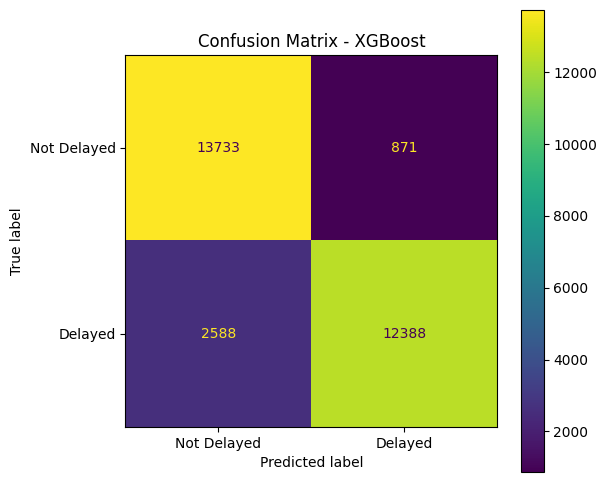

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Delayed", "Delayed"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(ax=ax)

plt.title("Confusion Matrix - XGBoost")

plt.show()

## Loading Target dataset

In [ ]:


target_df = pd.read_excel("/content/Target Data Set CS-22189.xlsx")


# Extract Group 2 Records

group2_df = pd.read_excel(
    "/content/Target Data Set CS-22189.xlsx",
    skiprows=16,
    nrows=10
)

print(group2_df.head())

print(group2_df.shape)

   Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  ArrTime  \
0   NaN    NaN           5          4   1455.0        1455      NaN   
1   NaN    NaN           5          4   1910.0        1900      NaN   
2   NaN    NaN           7          4    700.0         700      NaN   
3   NaN    NaN          12          4      NaN         645      NaN   
4   NaN    NaN          12          4    812.0         815      NaN   

   CRSArrTime UniqueCarrier  FlightNum  ... TaxiOut  Cancelled  \
0        1650            WN        227  ...     8.0          0   
1        2154            UA       1746  ...    11.0          0   
2         755            AS         60  ...     NaN          0   
3         937            UA        482  ...    10.0          1   
4        1000            US        103  ...    13.0          0   

   CancellationCode  Diverted  CarrierDelay WeatherDelay NASDelay  \
0               NaN         0           0.0          0.0      0.0   
1               NaN         0         

## Target dataset preprocessing

In [ ]:

# Creating Copy
target = group2_df.copy()


# Dropping Unnecessary Columns
target.drop(columns=[
    'ArrDelay',
    'DepDelay',
    'CancellationCode',
    'CarrierDelay',
    'WeatherDelay',
    'NASDelay',
    'SecurityDelay',
    'LateAircraftDelay',
    'Delayed'
], inplace=True)



In [ ]:
# Filling Missing Numeric Values
numeric_cols = target.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    target[col] = target[col].fillna(target[col].median())



In [ ]:
# Filling Missing Categorical Values

categorical_cols = target.select_dtypes(include=['object']).columns

for col in categorical_cols:
    target[col] = target[col].fillna("UNKNOWN")

In [ ]:

# Encoding Categorical Columns

from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()

categorical_columns = [
    'UniqueCarrier',
    'Origin',
    'Dest',
    'TailNum'
]

for col in categorical_columns:
    target[col] = le_target.fit_transform(target[col])

In [ ]:

# Filling Remaining Missing Values

target.fillna(0, inplace=True)

print(target.head())

print(target.shape)

   Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  ArrTime  \
0   0.0    0.0           5          4   1455.0        1455      0.0   
1   0.0    0.0           5          4   1910.0        1900      0.0   
2   0.0    0.0           7          4    700.0         700      0.0   
3   0.0    0.0          12          4    805.0         645      0.0   
4   0.0    0.0          12          4    812.0         815      0.0   

   CRSArrTime  UniqueCarrier  FlightNum  TailNum  ActualElapsedTime  \
0        1650              3        227        0               55.0   
1        2154              1       1746        5               98.0   
2         755              0         60        7               55.0   
3         937              1        482        6               91.0   
4        1000              2        103        3               91.0   

   CRSElapsedTime  Origin  Dest  Distance  TaxiIn  TaxiOut  Cancelled  \
0              55       1     0       277     5.0      8.0          0   



# reordering columns

In [ ]:


target = target[X_train.columns]

print(target.shape)



(10, 20)


In [ ]:
target_proba = best_model.predict_proba(target)[:, list(best_model.classes_).index(POSITIVE_LABEL)]
predictions = (target_proba >= best_threshold).astype(int)

group2_df["Predicted_Delayed"] = predictions
group2_df["Predicted_Delay_Probability"] = target_proba

group2_df[["Predicted_Delayed", "Predicted_Delay_Probability"]]

## Final predictions

In [ ]:
# Displaying Final Predictions

print("\nFinal Predictions for Group 2:\n")

for i, pred in enumerate(prediction_labels, start=1):
    print(f"Record {i}: {pred}")


Final Predictions for Group 2:

Record 1: Y
Record 2: Y
Record 3: N
Record 4: Y
Record 5: N
Record 6: N
Record 7: N
Record 8: Y
Record 9: Y
Record 10: N
